# Figures for methodology

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import cv2
import os
sys.path.append("../../src/")
sys.path.append("../../src/utils/")
sys.path.append("../../src/utils/IEBCS")

import eventIO
import event_representations

dotted ball and logo ball

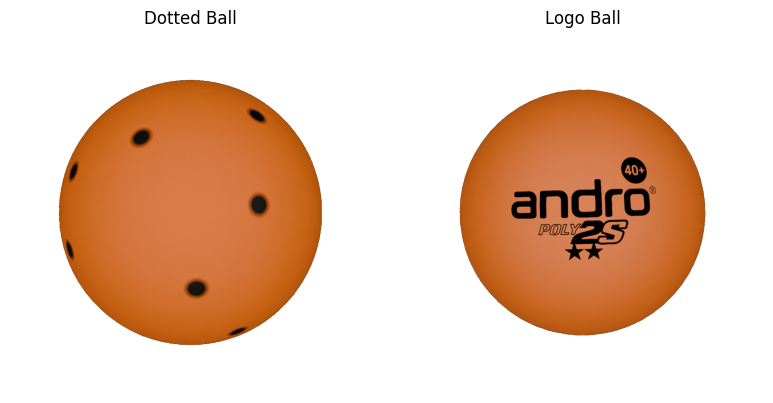

In [38]:
dotted = cv2.imread("figures/dotted_ball_transparent.png", cv2.IMREAD_UNCHANGED)
logo = cv2.imread("figures/logo_ball_transparent.png", cv2.IMREAD_UNCHANGED)

def bgr_to_rgb(img):
    if img is None:
        raise FileNotFoundError("Image not found: check path")
    # keep grayscale as is
    if img.ndim == 2:
        return img
    # convert BGRA -> RGBA or BGR -> RGB
    if img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    if img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

dotted = bgr_to_rgb(dotted)
logo = bgr_to_rgb(logo)
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(dotted)
ax[0].set_title("Dotted Ball")
ax[0].axis("off")
ax[1].imshow(logo)
ax[1].set_title("Logo Ball")
ax[1].axis("off")
plt.tight_layout()

Real, data vs. three sim runs

In [6]:
real_path = "/home/lkolmar/Documents/metavision/recordings/new_real_dataset/preprocessed/spin3_sidespin1_3.hdf5"   # spin 3 sidespin 1 recording 3

buf = eventIO.load_hdf5(real_path)
events = eventIO.buffer_to_array(buf)
sequence_real = event_representations.create_sequence(events, time_window=5000, num_bins=10)

sim_1_path = "/data/lkolmar/datasets/topspin_fit_to_max/preprocessed/00024/00024_roi.hdf5"
buf = eventIO.load_hdf5(sim_1_path)
events = eventIO.buffer_to_array(buf)
sequence_sim_1 = event_representations.create_sequence(events, time_window=5000, num_bins=10)

sim_2_path = "/data/lkolmar/datasets/realistic_topspin/preprocessed/00024/00024_roi.hdf5"
buf = eventIO.load_hdf5(sim_2_path)
events = eventIO.buffer_to_array(buf)
sequence_sim_2 = event_representations.create_sequence(events, time_window=5000, num_bins=10)

sim_3_path = "/data/lkolmar/datasets/spindoe_topspin/preprocessed/00000/00000_roi.hdf5"
buf = eventIO.load_hdf5(sim_3_path)
events = eventIO.buffer_to_array(buf)
sequence_sim_3 = event_representations.create_sequence(events, time_window=5000, num_bins=10)

In [7]:
img_real = sequence_real[9][2]
img_sim1 = np.rot90(sequence_sim_1[18][5], 2)  # rotate 180°
img_sim2 = sequence_sim_2[3][4]
img_sim3 = sequence_sim_3[3][4]

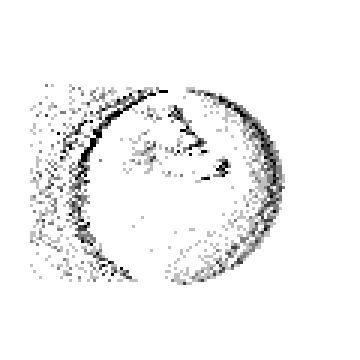

In [8]:
low, high = np.percentile(img_real, [1, 99])
fig, ax = plt.subplots(figsize=(1,1), dpi=300, facecolor='white')
ax.imshow(img_real, cmap='gray_r', interpolation='nearest', vmin=low, vmax=high)
ax.set_axis_off()
plt.tight_layout(pad=0)

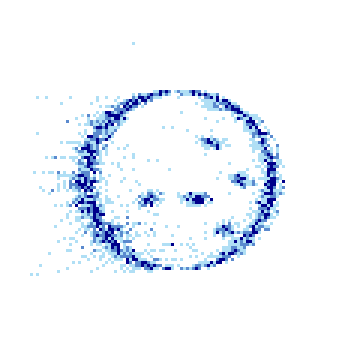

In [9]:
img = img_sim3
name = "sim_data_3"

low, high = np.percentile(img, [1, 99])
fig, ax = plt.subplots(figsize=(1,1), dpi=300, facecolor='white')
from matplotlib.colors import LinearSegmentedColormap
colors = ["white", "#89CFF0", "#00008B"]
cmap = LinearSegmentedColormap.from_list("white_blue", colors)
im = ax.imshow(img, interpolation='nearest', vmin=low, vmax=high, cmap=cmap)
ax.set_axis_off()
#cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
#cbar.set_label("Event count (clipped)", rotation=90, labelpad=8)
plt.tight_layout(pad=0)
plt.savefig("figures/" + name + ".png", dpi=300)

Bias table

In [ ]:
# sim:
th_pos: 0.05                                 # on threshold
th_neg: 0.05                                 # off threshold
th_n: 0.02                                   # noise threshold
lat: 150                                     # latency
tau: 200                                     # time constant
jit: 120                                     # jitter
bgn: 0.001                                   # background noise
ref_period: 10                               # ref-time of the event camera

# real:
0    # bias_diff
65   # bias_diff_off
65   # bias_diff_on
0    # bias_fo
0    # bias_hpf
0    # bias_refr

event rates

In [77]:
# real:
total_events = 19303
mean_logo_events = 124.4
logo_to_total_ratio = 0.00644
#print(mean_logo_events / total_events)
average_duration_s = 0.150

# first_sim
total_events = 29550
mean_logo_events = 673.1
logo_to_total_ratio = 0.02278
average_duration_s = 0.149

# second sim
total_events = 18323
mean_logo_events = 183.2
logo_to_total_ratio = 0.00999
#print(mean_logo_events / total_events)
average_duration_s = 0.149

# TODO: Setup Image

spike graph

Event rates (in ms): [2 0 0 ... 0 0 1]


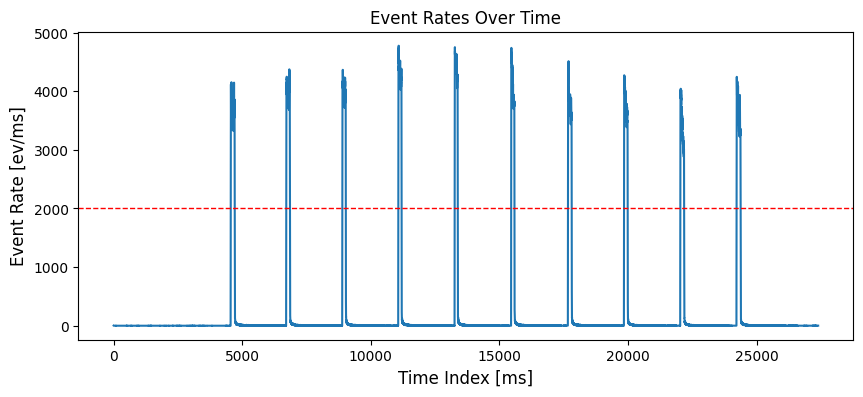

In [3]:
buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/hdf5/" + "spin_0_rec1_converted.hdf5")
event_rates = buf.ms_to_idx[1:] - buf.ms_to_idx[:-1]
print("Event rates (in ms):", event_rates)


plt.figure(figsize=(10, 4))
plt.plot(event_rates)
plt.axhline(y=2000, color='r', linestyle='--', linewidth=1)
plt.xlabel("Time Index [ms]")
plt.ylabel("Event Rate [ev/ms]")
plt.title("Event Rates Over Time")
ax = plt.gca()
title_size = ax.title.get_size()
ax.xaxis.label.set_size(title_size)
ax.yaxis.label.set_size(title_size)
plt.show()

kernel

In [90]:
# 11x11 Kreis-Umriss (Radius ≈ 5 px)
[
 [0,0,0,1,1,1,1,1,0,0,0],
 [0,0,1,1,0,0,0,1,1,0,0],
 [0,1,0,0,0,0,0,0,0,1,0],
 [1,1,0,0,0,0,0,0,0,1,1],
 [1,0,0,0,0,0,0,0,0,0,1],
 [1,0,0,0,0,0,0,0,0,0,1],
 [1,0,0,0,0,0,0,0,0,0,1],
 [1,1,0,0,0,0,0,0,0,1,1],
 [0,1,0,0,0,0,0,0,0,1,0],
 [0,0,1,1,0,0,0,1,1,0,0],
 [0,0,0,1,1,1,1,1,0,0,0]
]

[[0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
 [0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
 [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0]]

voxel

In [8]:
sim_2_path = "/data/lkolmar/datasets/realistic_topspin/preprocessed/00024/00024_roi.hdf5"
buf = eventIO.load_hdf5(sim_2_path)
events = eventIO.buffer_to_array(buf)
sequence_sim_2 = event_representations.create_sequence(events, time_window=5000, num_bins=10)
images = sequence_sim_2[3]

In [ ]:
img = img_sim3
name = "sim_data_3"

low, high = np.percentile(img, [1, 99])
fig, ax = plt.subplots(figsize=(1,1), dpi=300, facecolor='white')
from matplotlib.colors import LinearSegmentedColormap
colors = ["white", "#89CFF0", "#00008B"]
cmap = LinearSegmentedColormap.from_list("white_blue", colors)
im = ax.imshow(img, interpolation='nearest', vmin=low, vmax=high, cmap=cmap)
ax.set_axis_off()
#cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
#cbar.set_label("Event count (clipped)", rotation=90, labelpad=8)
plt.tight_layout(pad=0)
plt.savefig("figures/" + name + ".png", dpi=300)

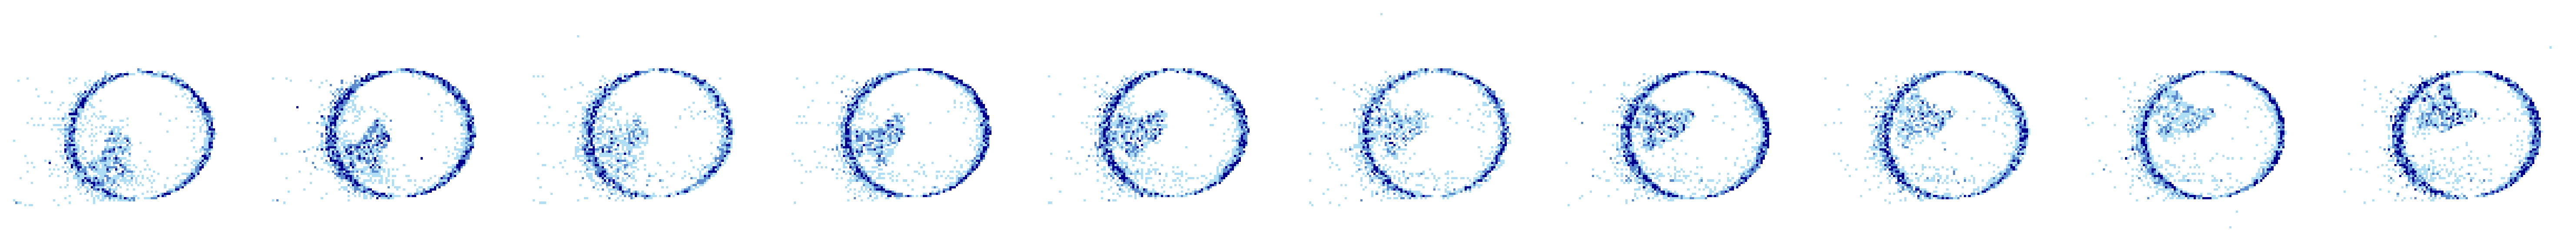

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2), dpi=300, facecolor='white')  # 1 Zeile, 10 Spalten
colors = ["white", "#89CFF0", "#00008B"]
cmap = LinearSegmentedColormap.from_list("white_blue", colors)
for ax, img in zip(axes, images):
    low, high = np.percentile(img, [1, 99])
    ax.imshow(img, interpolation='nearest', vmin=low, vmax=high, cmap=cmap)
    ax.axis("off")

plt.tight_layout()
plt.show()

nn plots

look chat, otherwise look out for good tool

# Spindoe Voxel

In [3]:
sim_2_path = "/data/lkolmar/datasets/spindoe_topspin/preprocessed/00024/00024_roi.hdf5"
buf = eventIO.load_hdf5(sim_2_path)
events = eventIO.buffer_to_array(buf)
sequence_sim_2 = event_representations.create_sequence(events, time_window=5000, num_bins=10)
images = sequence_sim_2[3]

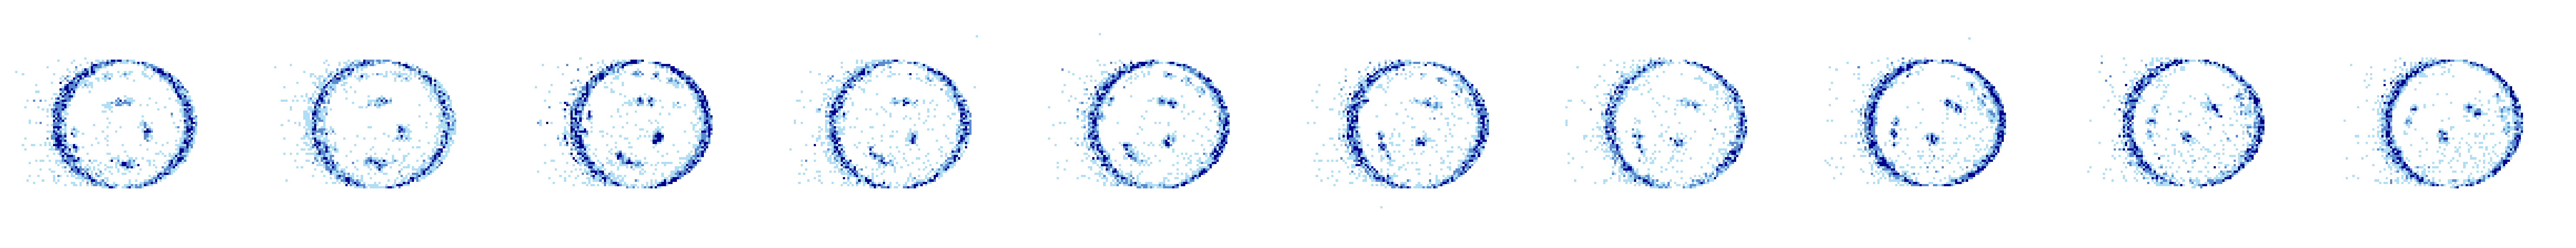

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2), dpi=300, facecolor='white')  # 1 Zeile, 10 Spalten
colors = ["white", "#89CFF0", "#00008B"]
cmap = LinearSegmentedColormap.from_list("white_blue", colors)
for ax, img in zip(axes, images):
    low, high = np.percentile(img, [1, 99])
    ax.imshow(img, interpolation='nearest', vmin=low, vmax=high, cmap=cmap)
    ax.axis("off")

plt.tight_layout()
plt.show()

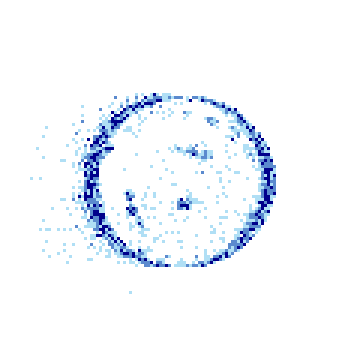

In [11]:
img = images[5]
name = "spindoe_voxel"

low, high = np.percentile(img, [1, 99])
fig, ax = plt.subplots(figsize=(1,1), dpi=300, facecolor='white')
from matplotlib.colors import LinearSegmentedColormap
colors = ["white", "#89CFF0", "#00008B"]
cmap = LinearSegmentedColormap.from_list("white_blue", colors)
im = ax.imshow(img, interpolation='nearest', vmin=low, vmax=high, cmap=cmap)
ax.set_axis_off()
#cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
#cbar.set_label("Event count (clipped)", rotation=90, labelpad=8)
plt.tight_layout(pad=0)
plt.savefig("figures/" + name + ".png", dpi=300)

In [4]:
import cv2
import time
import os
import sys

In [12]:
fourcc = cv2.VideoWriter_fourcc("M", "J", "P", "G")
video = cv2.VideoWriter("/home/lkolmar/Desktop/"+ "frames.avi", fourcc, 24, (1280, 720))

for i in range(1, 501):
    frame_path = f"/tmp/{str(i).zfill(4)}.png"
    frame = cv2.imread(frame_path)
    video.write(frame)

video.release()

In [7]:
ev = eventIO.load_hdf5("/data/lkolmar/datasets/realistic_topspin/preprocessed/00028/00028_roi.hdf5")

In [11]:
eventIO.create_video(ev, "/home/lkolmar/Desktop/event_video.avi", resolution=(100, 100), fps=22, tw=1000)

Creating video frames: 100%|██████████| 457/457 [00:01<00:00, 236.68frame/s]
